# TITANIC EDA AND PREDICTIVE MODELLING

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pointbiserialr, shapiro
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [14]:
ti_df = sns.load_dataset('titanic')

## Survival Analysis
The sinking of the Titanic is one of the most well documented maritime disasters in history. 
The question this notebook asks is simple: 
Given what we know about a passenger i.e. their age, sex, class, fare, and family situation can we predict whether they survived?
This turns out to be a binary classification problem. The target variable (survived) takes only two values 0 or 1. That single observation will drive every methodological choice made in this analysis.

## Prima Facie Analysis of Data

In [15]:
ti_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [16]:
ti_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [17]:
ti_df.shape

(891, 15)

891 passengers, 15 columns. Before building anything, it's worth understanding what we actually have and what's missing.

In [18]:
ti_df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## NULLS

In [19]:
ti_df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

## Conclusion and Remediation
Three columns have missing data worth addressing:
Age 177 missing values. Dropping these rows would lose ~20% of the dataset. Instead, missing ages are filled with the median age the median is preferred over the mean here because age distributions tend to be slightly right-skewed, and the median is more robust to that skew.
Deck 688 of 891 values missing. Over 75% of data is absent. No imputation strategy is defensible at this level of missingness this column is dropped.
Embarked — only 2 missing values. Filled with the mode (most common embarkation point).

In [22]:
#median imputation for age
ti_df['age'].fillna(ti_df['age'].median(), inplace=True)
#modal imputation for embark location
ti_df['embarked'].fillna(ti_df['embarked'].mode()[0], inplace=True)
#complete drop of 'deck' data
ti_df.drop(columns=['deck'], inplace=True)

C:\Users\Dushyant\AppData\Local\Temp\ipykernel_26076\1584676266.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ti_df['age'].fillna(ti_df['age'].median(), inplace=True)
C:\Users\Dushyant\AppData\Local\Temp\ipykernel_26076\1584676266.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

KeyError: "['deck'] not found in axis"

## EDA and Preliminary Patterns
Before touching a model, it's worth asking what the data actually shows. Who survived and who didn't and does the pattern make intuitive sense?

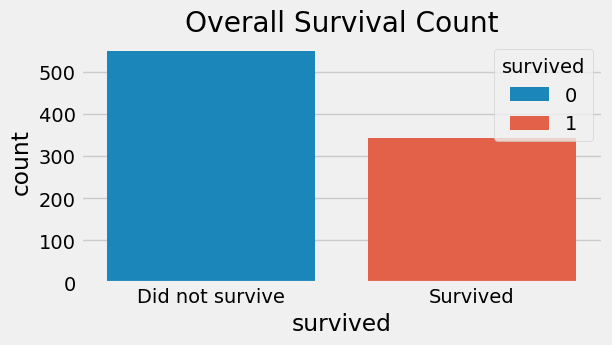

In [27]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(6,3))
sns.countplot(x='survived', data=ti_df, hue = 'survived' )
plt.title('Overall Survival Count')
plt.xticks([0,1], ['Did not survive', 'Survived'])
plt.show()

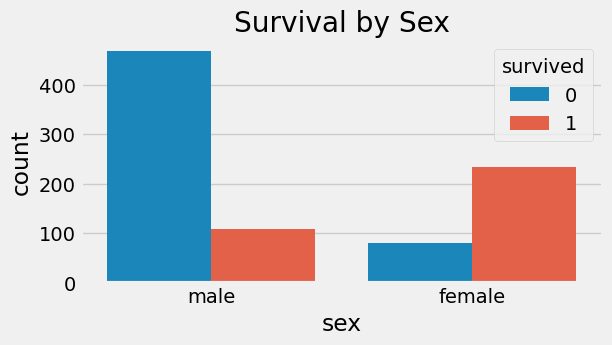

In [30]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(6,3))
sns.countplot(x='sex', hue='survived', data=ti_df)
plt.title('Survival by Sex')
plt.show()

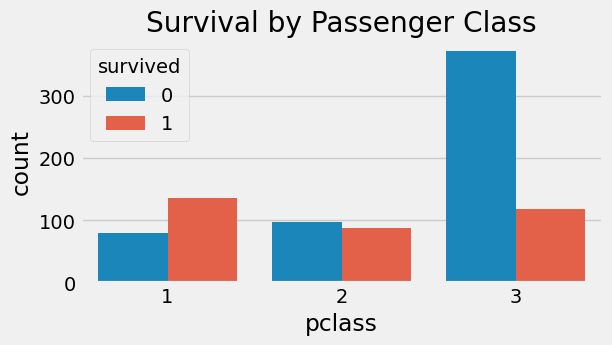

In [31]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(6,3))
sns.countplot(x='pclass', hue='survived', data=ti_df)
plt.title('Survival by Passenger Class')
plt.show()

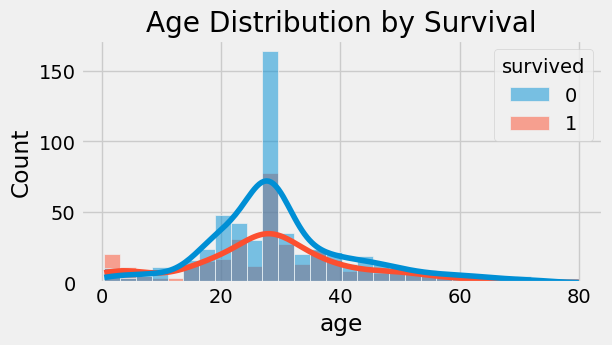

In [34]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(6,3))
sns.histplot(data=ti_df, x='age', hue='survived', bins=30, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

## RESULTS
The patterns are striking and historically consistent:

1) Female passengers survived at roughly 74% vs 19% for males the 'women and children first' evacuation protocol is visible directly in the data. 
2) First class passengers survived at nearly double the rate of third class passengers, likely reflecting both lifeboat proximity and the time it took lower deck passengers to reach the top.
3) Age is a weaker signal than sex or class, but children show a slightly elevated survival rate consistent with evacuation priority.

These observations inform which features we expect to matter most in the model.

## Feature Extrapolation

In [37]:
"""Two features are engineered from existing columns. SibSp (siblings/spouses) and Parch (parents/children) 
are combined into a single family_size feature as a passenger traveling with a large family may have faced 
different survival dynamics than one traveling alone. 
IsAlone is a binary flag derived directly from family_size. Sex and Embarked are categorical,
they need to be encoded as numbers before the model can use them. LabelEncoder assigns an integer to each category."""

ti_df['family_size'] = ti_df['sibsp'] + ti_df['parch']
ti_df['is_alone'] = (ti_df['family_size'] == 0).astype(int)

le = LabelEncoder()
ti_df['sex_encoded'] = le.fit_transform(ti_df['sex'])
ti_df['embarked_encoded'] = le.fit_transform(ti_df['embarked'].astype(str))

## Analysis of Correlation and Choosing the right correlation measure
### Pearson (continuous) vs Point Biserial (binary/binomial)
Before examining correlations, it's worth being precise about what correlation measure is appropriate for each variable type. The standard Pearson correlation coefficient assumes both variables are continuous. Applying it blindly across all features some of which are binary produces mathematically questionable results.
Pearson correlation measures the linear relationship between two continuous variables via their covariance normalized by their standard deviations. When one variable is binary (only takes values 0 and 1), the appropriate measure is the point-biserial correlation coefficient which is mathematically equivalent to Pearson but correctly interpreted for the binary case.
For this reason: continuous features are examined in a Pearson heatmap, and binary features are assessed against survival using point-biserial correlation individually.

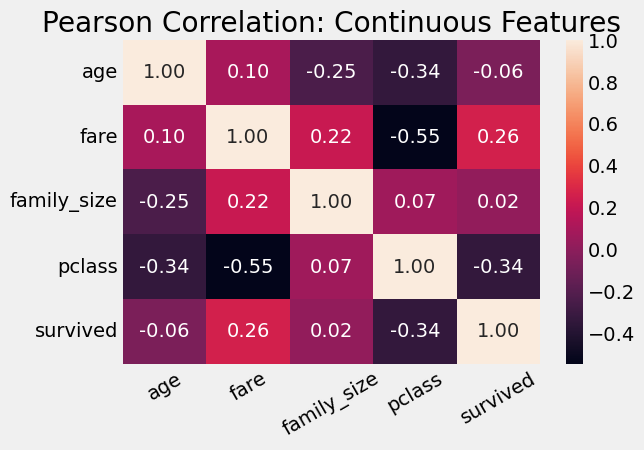

In [48]:
#Pearson Correlation Heatmap for Continuous Numeric Columns
plt.style.use('fivethirtyeight')
plt.figure(figsize=(6,4))
numeric_cols = ['age', 'fare', 'family_size', 'pclass', 'survived']
sns.heatmap(ti_df[numeric_cols].corr(), annot=True, fmt='.2f')
plt.title('Pearson Correlation: Continuous Features')
plt.xticks(rotation= 30)
plt.show()

In [51]:
# Point biserial heatmap for binary features
binary_features = ['sex_encoded', 'is_alone', 'embarked_encoded']
print("Point-biserial correlation with survival:\n")
for col in binary_features:
    corr, pval = pointbiserialr(ti_df[col], ti_df['survived'])
    print(f"  {col:25s}: r = {corr:+.3f},  p = {pval:.4f}")

Point-biserial correlation with survival:

  sex_encoded              : r = -0.543,  p = 0.0000
  is_alone                 : r = -0.203,  p = 0.0000
  embarked_encoded         : r = -0.168,  p = 0.0000


### ANOVA 
Before committing continuous features to the model, a one-way ANOVA tests whether their means differ significantly between survivors and non-survivors. A significant F-statistic (p < 0.05) indicates the feature carries signal worth including. This complements the Pearson correlation heatmap — correlation captures the direction and strength of the linear relationship, while ANOVA tests whether the group difference is statistically distinguishable from noise.

In [54]:
from scipy.stats import f_oneway

# Does mean fare differ significantly between survivors and non-survivors?
group0 = ti_df[ti_df['survived'] == 0]['fare']
group1 = ti_df[ti_df['survived'] == 1]['fare']

stat, p = f_oneway(group0, group1)
print(f"ANOVA — Fare by Survival: F = {stat:.3f}, p = {p:.4f}")

# Same for age
group0_age = ti_df[ti_df['survived'] == 0]['age']
group1_age = ti_df[ti_df['survived'] == 1]['age']

stat_age, p_age = f_oneway(group0_age, group1_age)
print(f"ANOVA — Age by Survival: F = {stat_age:.3f}, p = {p_age:.4f}")

ANOVA — Fare by Survival: F = 63.031, p = 0.0000
ANOVA — Age by Survival: F = 3.762, p = 0.0528


## Correlation Testing : Key Takeaways
Sex shows the strongest correlation with survival of any feature — consistent with what the EDA plots showed.
The p-values confirm these correlations are statistically significant (p < 0.05),
meaning they are unlikely to have occurred by chance in a dataset of this size.

These correlation results inform the order in which features are added to the model in the redundancy analysis below.

## Statistical Sanity checks for Logistic Regression:
Logistic regression is estimated via Maximum Likelihood Estimation (MLE), not Ordinary Least Squares like Numerical Regression.
Therefore the Gauss Markov conditions for regression sanity are now applied as:

A) The Relevant conditions:

    1) multicollinearity (breaks MLE estimation)
    2) Independence of observations (required for the likelihood to factorise correctly)
    3) Correct Functional Form (the log-odds relationship must be correctly specified)

B) Partially relevant but reframed:

    1) Linearity (becomes linearity in the log-odds rather than in the response)
    2) Exogeneity (omitted variable bias still exists and still matters)
    
C) Not directly relevant:

    1)Homoscedasticity (MLE doesn't assume constant error variance)
    2)Normality of errors (MLE doesn't require this; it specifies the distribution explicitly as Bernoulli)

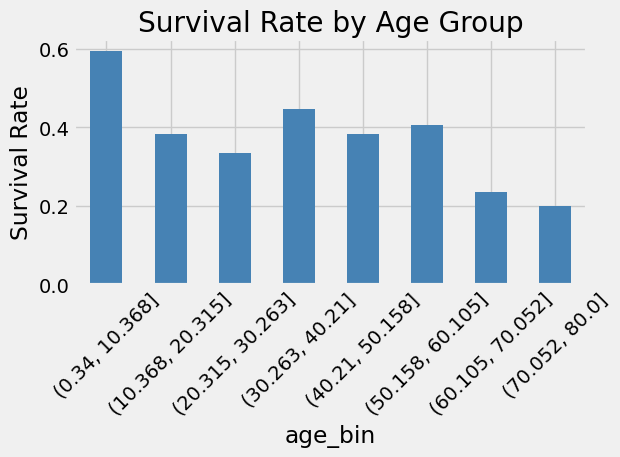

In [57]:
#LINEARITY CHECK
ti_df['age_bin'] = pd.cut(ti_df['age'], bins=8)
ti_df.groupby('age_bin', observed=True)['survived'].mean().plot(kind='bar', color='steelblue')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## LINEAR VS LOGISTIC REGRESSION AND THE LOG LOSS
Why logistic regression and not linear regression?
The target variable survived takes only two values: 0 or 1. If we fit a standard linear regression to this, nothing stops the model from predicting 1.7 or -0.3 values that are meaningless as probabilities.
What we actually need is a model that outputs a probability between 0 and 1. Logistic regression achieves this by modeling the log-odds of survival as a linear function of features:
##### log(p / 1-p) = β₀ + β₁x₁ + β₂x₂ + ...
Solving this equation for p gives the sigmoid function a smooth S-curve that maps any real number to a value between 0 and 1. The sigmoid wasn't chosen arbitrarily; it falls out algebraically from the log-odds formulation.
Geometrically, the model draws a hyperplane in feature space. On one side, the model assigns high probability of survival. On the other, low probability. The sigmoid controls how sharply that transition happens.
The model is trained by minimizing log-loss (binary cross-entropy):
##### Loss = -[y·log(p) + (1-y)·log(1-p)]
Where y is the true label and p is the predicted probability. This is equivalent to maximizing the binomial likelihood across all passengers — each passenger is effectively a Bernoulli trial (survived or didn't), and log-loss is the negative log of that likelihood function. Minimizing log-loss and maximizing binomial likelihood are the same operation.

In [58]:
# Train test split
features = ['sex_encoded', 'pclass', 'age', 'fare', 
            'family_size', 'is_alone', 'embarked_encoded']
X = ti_df[features]
y = ti_df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
# VIF CHECK
'''Variance Inflation Factor (VIF) measures how much the variance of a coefficient estimate is inflated due to correlation with other predictors.
A VIF of 1 means no correlation with other features. VIF > 5 is typically considered problematic.
Family_size and is_alone are structurally related by construction — is_alone is derived directly from family_size.
Some collinearity between them is expected. The sequential analysis below will show whether this actually hurts the model.'''
X_vif = ti_df[features].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(X_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

            feature       VIF
1            pclass  7.229636
5          is_alone  5.279980
2               age  4.852723
6  embarked_encoded  4.777060
0       sex_encoded  3.164600
4       family_size  2.787351
3              fare  1.682471


In [63]:
# Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [64]:
# Evaluation
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred, 
      target_names=['Did not survive', 'Survived']))

Accuracy: 0.7989

                 precision    recall  f1-score   support

Did not survive       0.81      0.86      0.83       105
       Survived       0.78      0.72      0.75        74

       accuracy                           0.80       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179



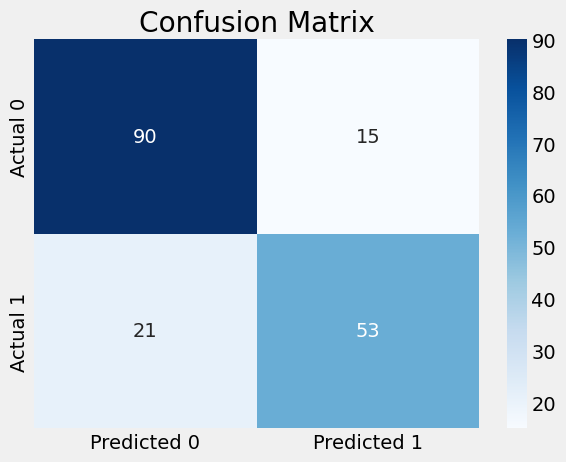

In [65]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.show()

## TEST Results
#### The model achieves ~80% accuracy. Looking at the classification report more carefully precision and recall differ between the two classes. This reflects a mild class imbalance in the dataset (more passengers did not survive than survived). Precision answers: of all passengers the model predicted survived, what fraction actually did?
Recall answers: of all passengers who actually survived, what fraction did the model correctly identify?
Depending on the application, one matters more than the other. In a medical diagnosis context you'd prioritize recall — missing a survivor is worse than a false alarm. Here both matter roughly equally.

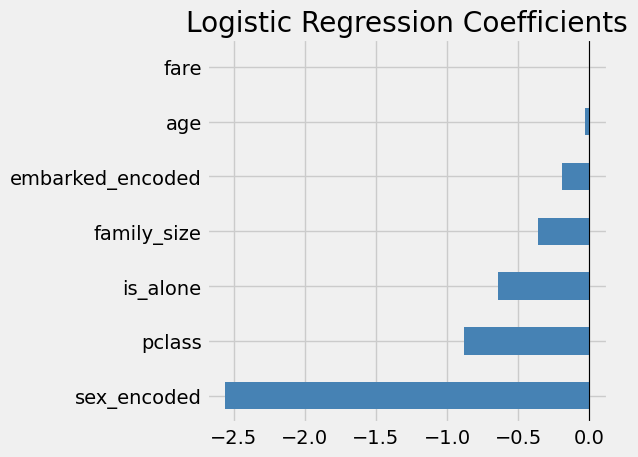

In [66]:
# Feature Coefficients
importance = pd.Series(
    model.coef_[0],
    index=features
).sort_values()

importance.plot(kind='barh', color='steelblue')
plt.title('Logistic Regression Coefficients')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

The coefficient magnitudes confirm what the EDA suggested — sex is the dominant predictor. A large negative coefficient on sex_encoded (where male=1) reflects the strong survival disadvantage for male passengers.
Passenger class has a negative coefficient — higher class number (3rd class) is associated with lower survival probability, consistent with the countplot earlier.
These coefficients operate on the log-odds scale — a one unit increase in a feature shifts the log-odds of survival by the coefficient value

      feature_added  n_features  mcfadden_r2
0       sex_encoded           1       0.2266
1            pclass           2       0.3029
2               age           3       0.3211
3              fare           4       0.3212
4       family_size           5       0.3334
5          is_alone           6       0.3401
6  embarked_encoded           7       0.3423


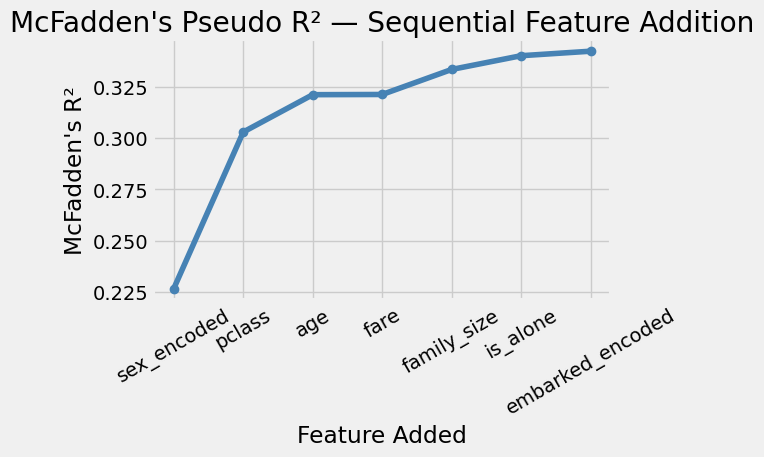

In [69]:
## Degrees of Freedom vs Model Performace : Sequential McFadden Test
features_sequential = [
    ['sex_encoded'],
    ['sex_encoded', 'pclass'],
    ['sex_encoded', 'pclass', 'age'],
    ['sex_encoded', 'pclass', 'age', 'fare'],
    ['sex_encoded', 'pclass', 'age', 'fare', 'family_size'],
    ['sex_encoded', 'pclass', 'age', 'fare', 'family_size', 'is_alone'],
    ['sex_encoded', 'pclass', 'age', 'fare', 'family_size', 
     'is_alone', 'embarked_encoded']
]

results = []
for feature_set in features_sequential:
    X_temp = ti_df[feature_set].dropna()
    y_temp = ti_df.loc[X_temp.index, 'survived']
    X_const = sm.add_constant(X_temp)
    model_sm = sm.Logit(y_temp, X_const).fit(disp=0)
    mcfadden = 1 - (model_sm.llf / model_sm.llnull)
    results.append({
        'feature_added': feature_set[-1],
        'n_features': len(feature_set),
        'mcfadden_r2': round(mcfadden, 4)
    })

results_df = pd.DataFrame(results)
print(results_df)

plt.plot(results_df['n_features'], results_df['mcfadden_r2'], 
         marker='o', color='steelblue')
plt.xticks(results_df['n_features'], 
           results_df['feature_added'], rotation=30)
plt.title("McFadden's Pseudo R² — Sequential Feature Addition")
plt.ylabel("McFadden's R²")
plt.xlabel("Feature Added")
plt.tight_layout()
plt.show()

## Where does adding features stop helping?
R² in ordinary linear regression measures how much variance in the outcome the model explains — and adjusted R² penalizes adding features that don't genuinely improve this, correcting for the degrees of freedom spent.
Logistic regression doesn't minimize squared errors so there's no direct R². The equivalent is McFadden's Pseudo R², defined as:
McFadden's R² = 1 - (log-likelihood of model / log-likelihood of null model)
A null model predicts the same probability for every passenger (the base rate). McFadden's R² measures how much the fitted model improves on this baseline. Values above 0.2 are generally considered good for logistic regression.
Features are added in descending order of their correlation with survival — strongest predictors first. A large jump in McFadden's R² means that feature contributed genuine new information. A flat section means the additional features are spending degrees of freedom without meaningfully improving the model — the same signal the adjusted R² penalty captures in OLS

# Summary
##### Sex and passenger class are by far the strongest predictors of survival — together they account for the majority of the model's explanatory power, visible in the sharp early rise in McFadden's R². Additional features contribute diminishing returns.The analysis deliberately examined several assumptions underlying regression before and after fitting the model. Two are worth flagging as genuine limitations: this dataset is a census rather than a random sample, which constrains inference to this specific voyage rather than any broader population. And there are almost certainly omitted variables — lifeboat access, deck positioning, social connections aboard — that correlate with both the predictors and survival, introducing bias that cannot be corrected from the available data alone. Model accuracy of ~80% is consistent with published benchmarks on this dataset.

### - Dushyant Singh Taggar